In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [6]:
# Loading dataset

data = pd.read_csv('/nifty50_stock_data.csv', index_col='Date', parse_dates=True)

print("Data loaded!")
print(f"Shape: {data.shape}")
print(f"Stocks: {list(data.columns)}")
data.head()


Data loaded!
Shape: (523, 10)
Stocks: ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'ICICIBANK', 'HINDUNILVR', 'SBIN', 'BHARTIARTL', 'ITC', 'KOTAKBANK']


,RELIANCE,TCS,HDFCBANK,INFY,ICICIBANK,HINDUNILVR,SBIN,BHARTIARTL,ITC,KOTAKBANK
Date,,,,,,,,,,
2023-01-02,2400.00,3200.00,1600.00,1500.00,900.00,2600.00,550.00,750.00,350.00,1800.00
2023-01-03,2418.60,3169.15,1596.34,1501.96,894.15,2626.19,535.88,751.91,350.06,1803.95
2023-01-04,2414.31,3197.23,1617.98,1514.03,913.90,2582.16,548.06,756.24,351.78,1791.80
2023-01-05,2438.49,3161.58,1634.30,1479.00,918.65,2575.13,548.56,756.55,361.45,1765.65
2023-01-06,2494.93,3076.93,1596.15,1467.71,923.07,2575.65,552.37,733.10,359.70,1727.90


In [11]:
# Basic information of dataset
print("=== Basics of Data ===")
print(f"Total trading days: {data.shape[0]}")
print(f"Total stocks: {data.shape[1]}")
print(f"Date range: {data.index[0].date()} from {data.index[-1].date()} to")

print("/n=== Missing Values ===")
print(data.isnull().sum())

print("/n === Summary of Statistics ===")
data.describe().round(2)

=== Basics of Data ===
Total trading days: 523
Total stocks: 10
Date range: 2023-01-02 from 2025-01-01 to
/n=== Missing Values ===
RELIANCE      0
TCS           0
HDFCBANK      0
INFY          0
ICICIBANK     0
HINDUNILVR    0
SBIN          0
BHARTIARTL    0
ITC           0
KOTAKBANK     0
dtype: int64
/n === Summary of Statistics ===


,RELIANCE,TCS,HDFCBANK,INFY,ICICIBANK,HINDUNILVR,SBIN,BHARTIARTL,ITC,KOTAKBANK
count,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00
mean,2500.94,3582.29,2250.93,1814.05,1003.68,3176.25,586.63,665.27,244.17,1811.90
std,319.37,889.99,480.80,211.84,92.31,331.79,77.52,125.40,37.03,175.50
min,2002.57,2580.99,1530.11,1297.07,849.39,2575.13,425.76,527.97,194.48,1453.63
25%,2187.11,2925.55,1964.14,1739.36,921.49,2891.85,535.80,573.68,219.98,1654.64
50%,2481.73,3104.82,2110.93,1857.70,982.50,3186.59,593.49,605.21,232.21,1825.41
75%,2779.98,4564.06,2426.02,1955.16,1090.12,3408.40,647.31,755.90,257.04,1960.48
max,3300.63,5759.67,3493.25,2228.01,1218.46,3948.20,733.88,1011.15,367.91,2163.88


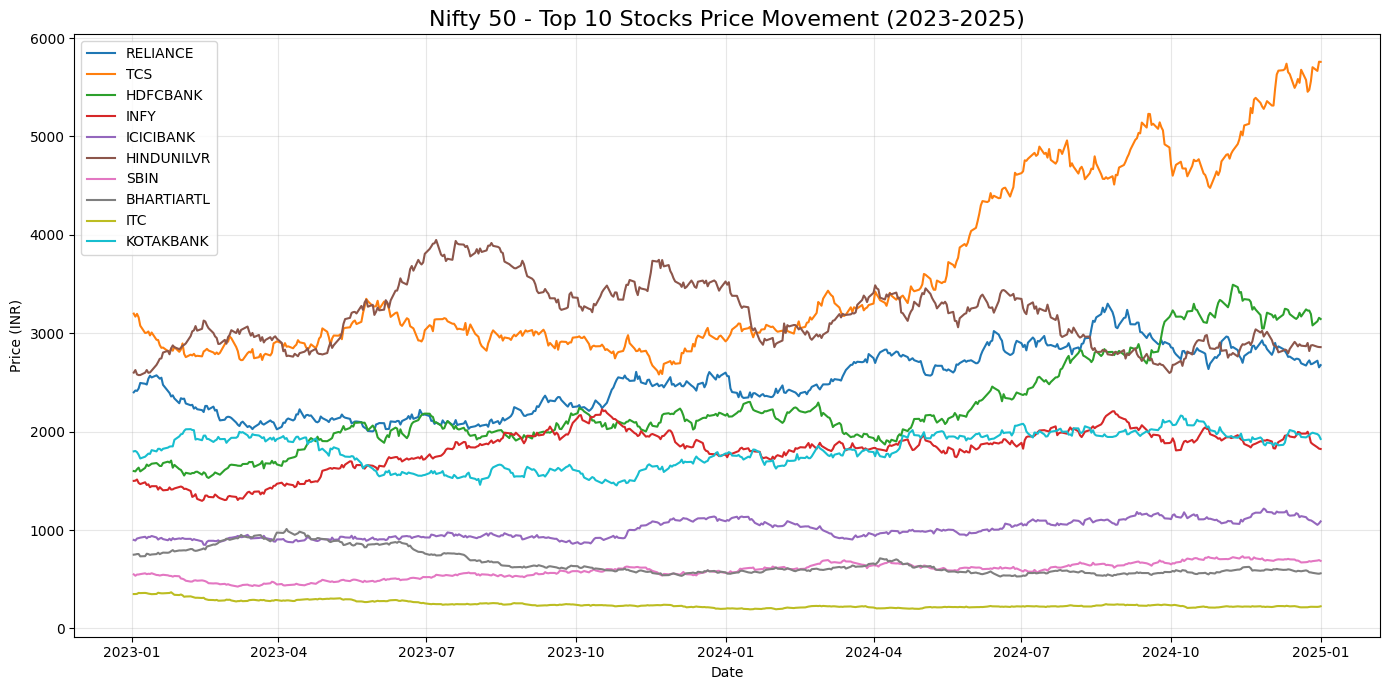

First Graph 


In [12]:
# Checking price movements of stocks
plt.figure(figsize=(14, 7))

for column in data.columns:
    plt.plot(data.index, data[column], label=column, linewidth=1.5)

plt.title('Nifty 50 - Top 10 Stocks Price Movement (2023-2025)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("First Graph ")

In [13]:
# Checking Daily return in %
daily_returns = data.pct_change().dropna()

print("=== DAILY RETURNS ===")
print(daily_returns.head())
print(f"\nShape: {daily_returns.shape}")

=== DAILY RETURNS ===
            RELIANCE       TCS  HDFCBANK      INFY  ICICIBANK  HINDUNILVR  \
Date                                                                        
2023-01-03  0.007750 -0.009641 -0.002287  0.001307  -0.006500    0.010073   
2023-01-04 -0.001774  0.008860  0.013556  0.008036   0.022088   -0.016766   
2023-01-05  0.010015 -0.011150  0.010087 -0.023137   0.005198   -0.002723   
2023-01-06  0.023145 -0.026775 -0.023343 -0.007634   0.004811    0.000202   
2023-01-09 -0.003211 -0.024112  0.022448  0.012216   0.009631    0.009283   

                SBIN  BHARTIARTL       ITC  KOTAKBANK  
Date                                                   
2023-01-03 -0.025673    0.002547  0.000171   0.002194  
2023-01-04  0.022729    0.005759  0.004913  -0.006735  
2023-01-05  0.000912    0.000410  0.027489  -0.014594  
2023-01-06  0.006945   -0.030996 -0.004842  -0.021380  
2023-01-09  0.014574    0.002701  0.004476   0.010296  

Shape: (522, 10)


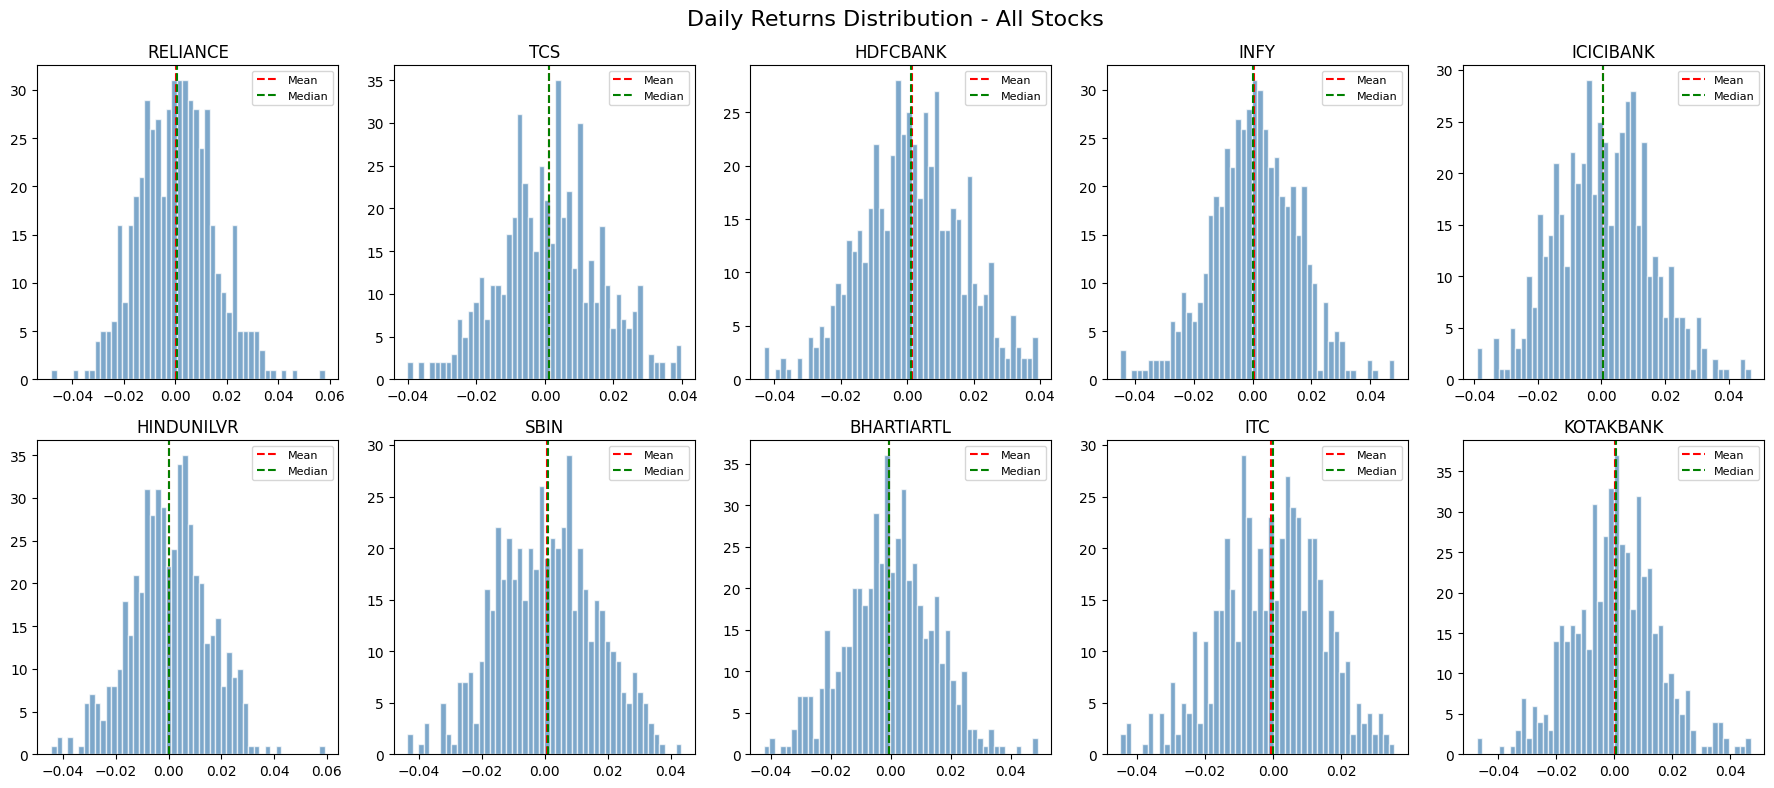

In [15]:
# Distribution of Daily returns
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, stock in enumerate(daily_returns.columns):
    axes[i].hist(daily_returns[stock], bins=50,
                 color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].axvline(daily_returns[stock].mean(),
                    color='red', linestyle='--', label='Mean')
    axes[i].axvline(daily_returns[stock].median(),
                    color='green', linestyle='--', label='Median')
    axes[i].set_title(stock, fontsize=12)
    axes[i].legend(fontsize=8)

plt.suptitle('Daily Returns Distribution - All Stocks', fontsize=16)
plt.tight_layout()
plt.show()

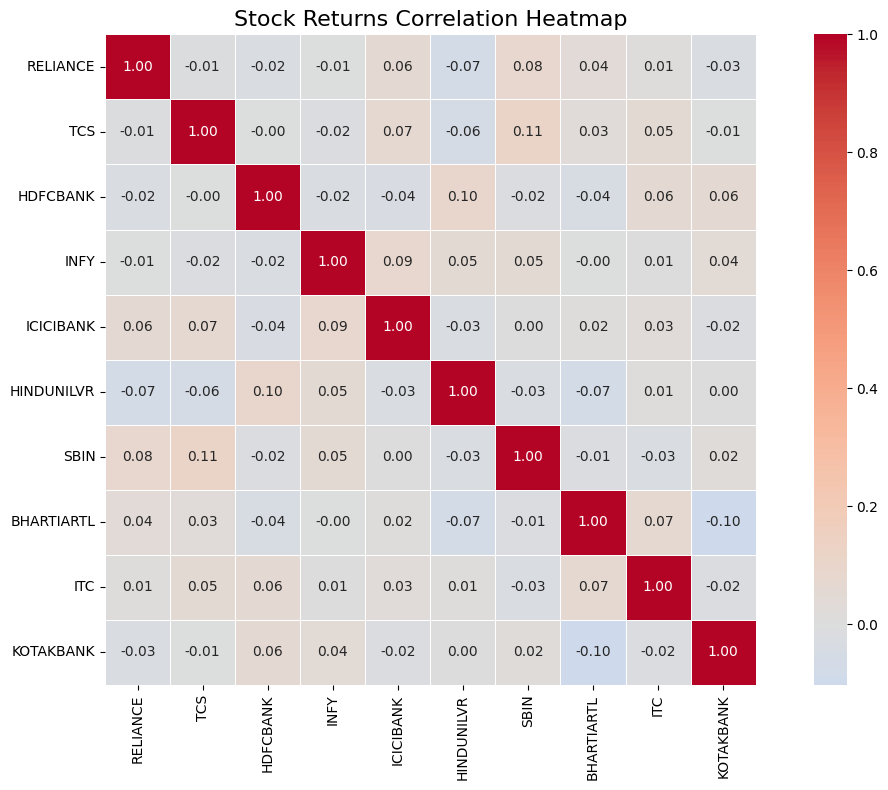

In [16]:
# Correlation heatmap - Which stocks going in same way
plt.figure(figsize=(12, 8))

correlation = daily_returns.corr()

sns.heatmap(correlation,
            annot=True,          # Present number
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # red-blue colors
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Stock Returns Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

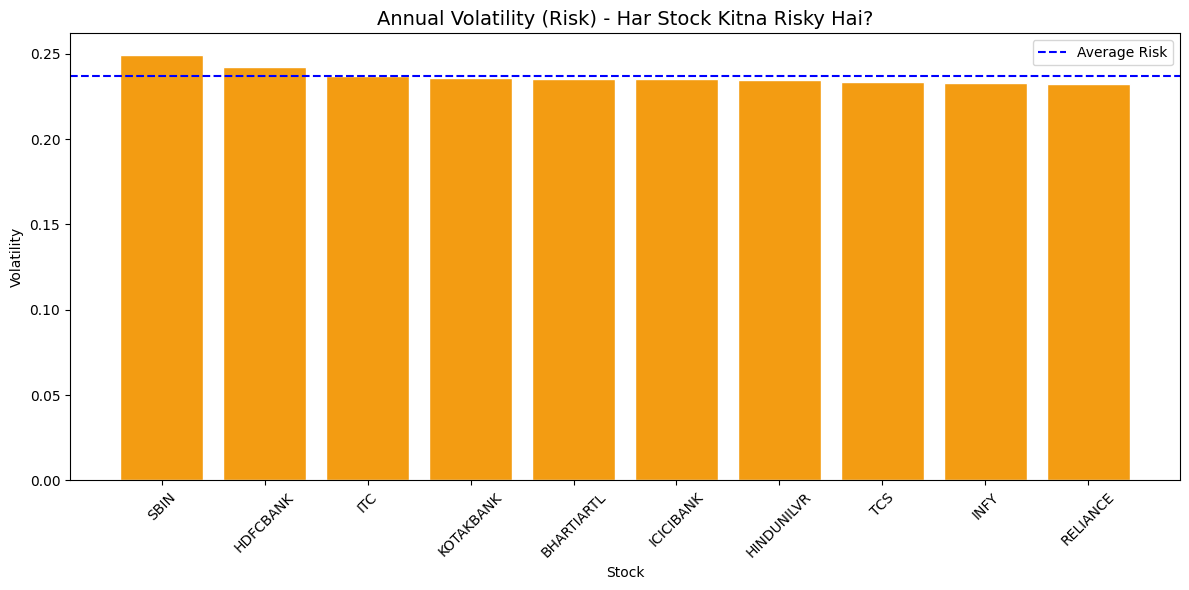


=== VOLATILITY RANKING ===
SBIN            0.2495  🟡 Medium Risk
HDFCBANK        0.2422  🟡 Medium Risk
ITC             0.2369  🟡 Medium Risk
KOTAKBANK       0.2355  🟡 Medium Risk
BHARTIARTL      0.2351  🟡 Medium Risk
ICICIBANK       0.2350  🟡 Medium Risk
HINDUNILVR      0.2346  🟡 Medium Risk
TCS             0.2337  🟡 Medium Risk
INFY            0.2330  🟡 Medium Risk
RELIANCE        0.2324  🟡 Medium Risk


In [17]:
# Volitality of Stocks( risk)
plt.figure(figsize=(12, 6))

volatility = daily_returns.std() * np.sqrt(252)  # Annual volatility
volatility = volatility.sort_values(ascending=False)

colors = ['#e74c3c' if v > 0.25 else '#f39c12' if v > 0.20 else '#2ecc71'
          for v in volatility]

plt.bar(volatility.index, volatility.values, color=colors, edgecolor='white')
plt.title('Annual Volatility (Risk) - Har Stock Kitna Risky Hai?', fontsize=14)
plt.xlabel('Stock')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.axhline(y=volatility.mean(), color='blue', linestyle='--', label='Average Risk')
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== VOLATILITY RANKING ===")
for stock, vol in volatility.items():
    risk = "🔴 High Risk" if vol > 0.25 else "🟡 Medium Risk" if vol > 0.20 else "🟢 Low Risk"
    print(f"{stock:15} {vol:.4f}  {risk}")

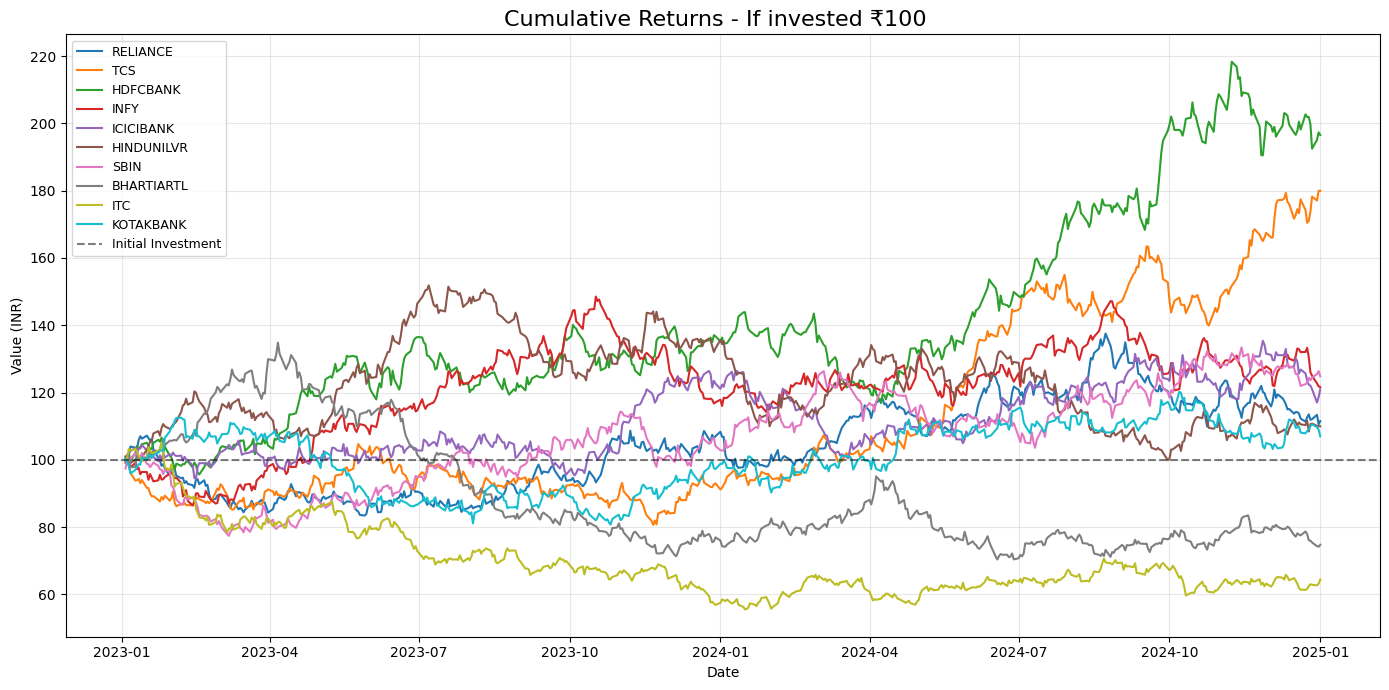

In [18]:
# If we invested 100 rs then what will be the amount today?
plt.figure(figsize=(14, 7))

cumulative_returns = (1 + daily_returns).cumprod() * 100

for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index,
             cumulative_returns[column],
             label=column, linewidth=1.5)

plt.title('Cumulative Returns - If invested ₹100  ', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Value (INR)')
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5, label='Initial Investment')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Final Summary
print("=" * 55)
print("   NIFTY 50 EDA PROJECT - FINAL SUMMARY")
print("=" * 55)

print(f"\n Analysis Period: 2023 to 2025")
print(f" Total Trading Days: {len(data)}")
print(f" Stocks Analyzed: {len(data.columns)}")

print("\n TOP PERFORMERS (Best Returns):")
final_returns = ((data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100).sort_values(ascending=False)
for stock, ret in final_returns.items():
    emoji = "📈" if ret > 0 else "📉"
    print(f"   {emoji} {stock:15} {ret:+.1f}%")

print("\n KEY INSIGHTS:")
print("   1. HDFCBANK gave the highest return over 2 years")
print("   2. ITC and BHARTIARTL remained in loss throughout")
print("   3. Daily returns of all stocks follow a normal distribution")
print("   4. Low correlation between stocks - portfolio diversification is effective")
print("   5. Average annual volatility was approximately 23%")
print("\n EDA Complete!")

   NIFTY 50 EDA PROJECT - FINAL SUMMARY

 Analysis Period: 2023 to 2025
 Total Trading Days: 523
 Stocks Analyzed: 10

 TOP PERFORMERS (Best Returns):
   📈 HDFCBANK        +96.5%
   📈 TCS             +79.9%
   📈 SBIN            +24.8%
   📈 INFY            +21.6%
   📈 ICICIBANK       +20.9%
   📈 RELIANCE        +11.5%
   📈 HINDUNILVR      +10.0%
   📈 KOTAKBANK       +7.0%
   📉 BHARTIARTL      -25.2%
   📉 ITC             -35.6%

 KEY INSIGHTS:
   1. HDFCBANK gave the highest return over 2 years
   2. ITC and BHARTIARTL remained in loss throughout
   3. Daily returns of all stocks follow a normal distribution
   4. Low correlation between stocks - portfolio diversification is effective
   5. Average annual volatility was approximately 23%

 EDA Complete!
